In [63]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
(x_train, y_train) , (x_test, y_test)= keras.datasets.mnist.load_data()

In [65]:
len(x_train) , len(x_test)

(60000, 10000)

In [66]:
x_train.shape

(60000, 28, 28)

In [67]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

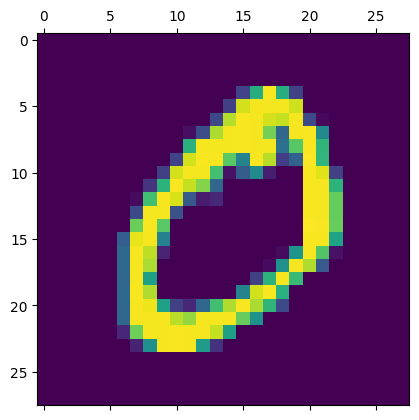

In [68]:
plt.matshow(x_train[1])

In [69]:
x_train.shape

(60000, 28, 28)

In [70]:
x_train= x_train /255
x_test= x_test /255

In [71]:
# now need to convert to 1D array
# that is (60000, 784)
x_train_flattened= x_train.reshape(len(x_train), 28*28)
x_test_flattened= x_test.reshape(len(x_test), 28*28)

x_train_flattened

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [72]:
x_train_flattened.shape

(60000, 784)

In [73]:
y_train.shape

(60000,)

In [74]:
x_test_flattened.shape

(10000, 784)

In [75]:
x_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [76]:
model= keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,), activation='sigmoid')])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 3s 818us/step - loss: 0.4705 - accuracy: 0.8769
Epoch 2/5
1875/1875 [==============================] - 1s 716us/step - loss: 0.3039 - accuracy: 0.9153
Epoch 3/5
1875/1875 [==============================] - 1s 712us/step - loss: 0.2832 - accuracy: 0.9213
Epoch 4/5
1875/1875 [==============================] - 1s 732us/step - loss: 0.2736 - accuracy: 0.9239
Epoch 5/5
1875/1875 [==============================] - 1s 717us/step - loss: 0.2663 - accuracy: 0.9257


In [77]:
model.evaluate(x_test_flattened, y_test)

313/313 [==============================] - 0s 708us/step - loss: 0.2653 - accuracy: 0.9280


[0.2653103470802307, 0.9279999732971191]

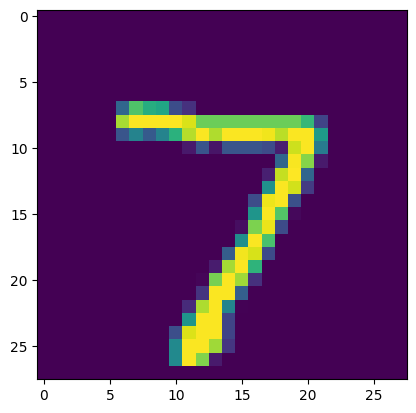

In [78]:
plt.imshow(x_test[0])

In [79]:
y_pred= model.predict(x_test_flattened)
y_pred[0:5]

313/313 [==============================] - 0s 663us/step


array([[2.4996515e-02, 2.7160380e-07, 9.5504001e-02, 9.4360828e-01,
        3.0332925e-03, 1.2440052e-01, 2.0020805e-06, 9.9981892e-01,
        8.0821864e-02, 6.0375184e-01],
       [3.7412798e-01, 6.2754638e-03, 9.9927163e-01, 3.5053053e-01,
        8.5128227e-10, 8.4569108e-01, 9.0881681e-01, 1.8837169e-12,
        1.3731872e-01, 2.8785931e-09],
       [4.1507039e-04, 9.9309820e-01, 5.6531930e-01, 2.7694640e-01,
        2.3264760e-02, 9.0719737e-02, 1.1669811e-01, 1.4198850e-01,
        3.7378287e-01, 3.5394426e-02],
       [9.9935222e-01, 2.9987909e-08, 1.1207371e-01, 6.1114575e-03,
        4.6726505e-05, 8.6072430e-02, 7.8533202e-02, 1.3695854e-02,
        2.1773018e-02, 1.3502918e-02],
       [2.9724145e-02, 3.8833554e-05, 1.6104783e-01, 3.2253989e-03,
        9.8669493e-01, 1.2400568e-02, 1.5526636e-01, 1.7214108e-01,
        1.9279131e-01, 7.1661258e-01]], dtype=float32)

In [80]:
np.argmax(y_pred[0])

7

In [81]:
y_pred_label= [np.argmax(i) for i in y_pred]
y_pred_label[:5]

[7, 2, 1, 0, 4]

In [82]:
y_test[0:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [83]:
cm= tf.math.confusion_matrix(labels=y_test, predictions=y_pred_label)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 963,    0,    2,    2,    0,    4,    6,    2,    1,    0],
       [   0, 1115,    3,    2,    0,    1,    4,    2,    8,    0],
       [   6,   10,  925,   18,    8,    2,   13,   10,   36,    4],
       [   2,    0,   18,  919,    0,   29,    2,   14,   19,    7],
       [   2,    1,    4,    1,  922,    0,    8,    4,    9,   31],
       [  10,    3,    2,   31,    8,  784,   16,    4,   28,    6],
       [  14,    3,    4,    1,    7,   11,  914,    2,    2,    0],
       [   1,    5,   23,    4,    8,    1,    0,  961,    2,   23],
       [   7,   10,    5,   20,   10,   27,    9,   13,  867,    6],
       [  11,    7,    1,    9,   30,    6,    0,   29,    6,  910]])>

<Axes: >

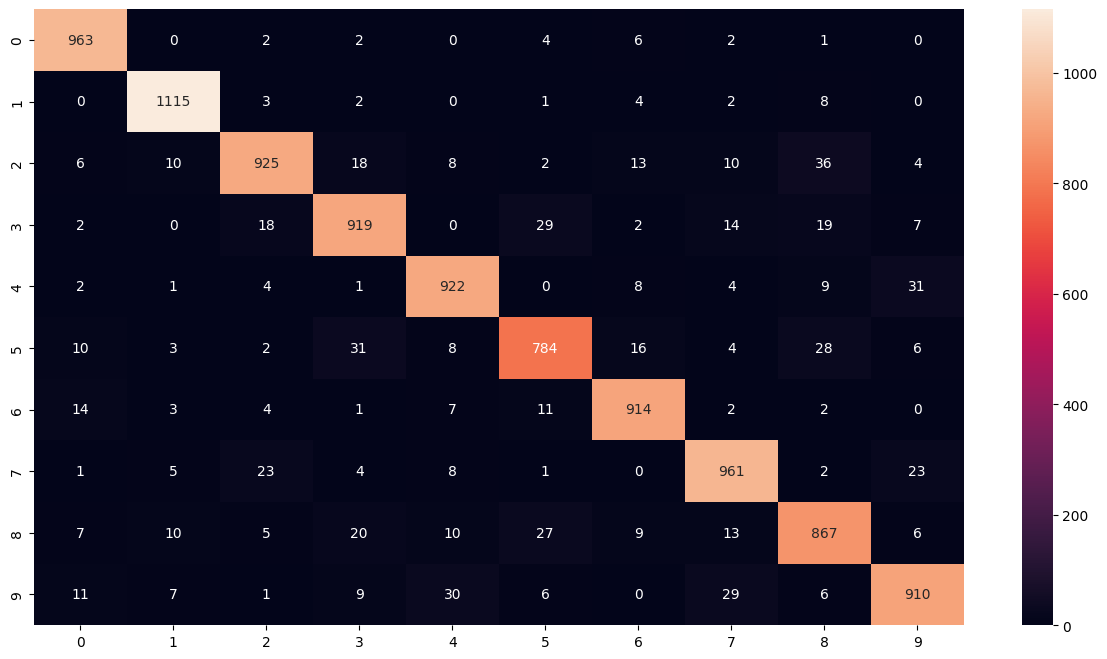

In [84]:
import seaborn as sns
plt.figure(figsize=(15,8))
sns. heatmap(data= cm, annot=True,fmt='d')

In [85]:
model= keras.Sequential([keras.layers.Dense(100, input_shape=(784,), activation='relu'),
                         keras.layers.Dense(10, activation='sigmoid')])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.2784 - accuracy: 0.9207
Epoch 2/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.1233 - accuracy: 0.9632
Epoch 3/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0844 - accuracy: 0.9744
Epoch 4/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0640 - accuracy: 0.9807
Epoch 5/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0498 - accuracy: 0.9847


In [87]:
model.evaluate(x_test_flattened, y_test)

313/313 [==============================] - 0s 882us/step - loss: 0.0869 - accuracy: 0.9727


[0.08688531816005707, 0.9726999998092651]

313/313 [==============================] - 0s 695us/step


<Axes: >

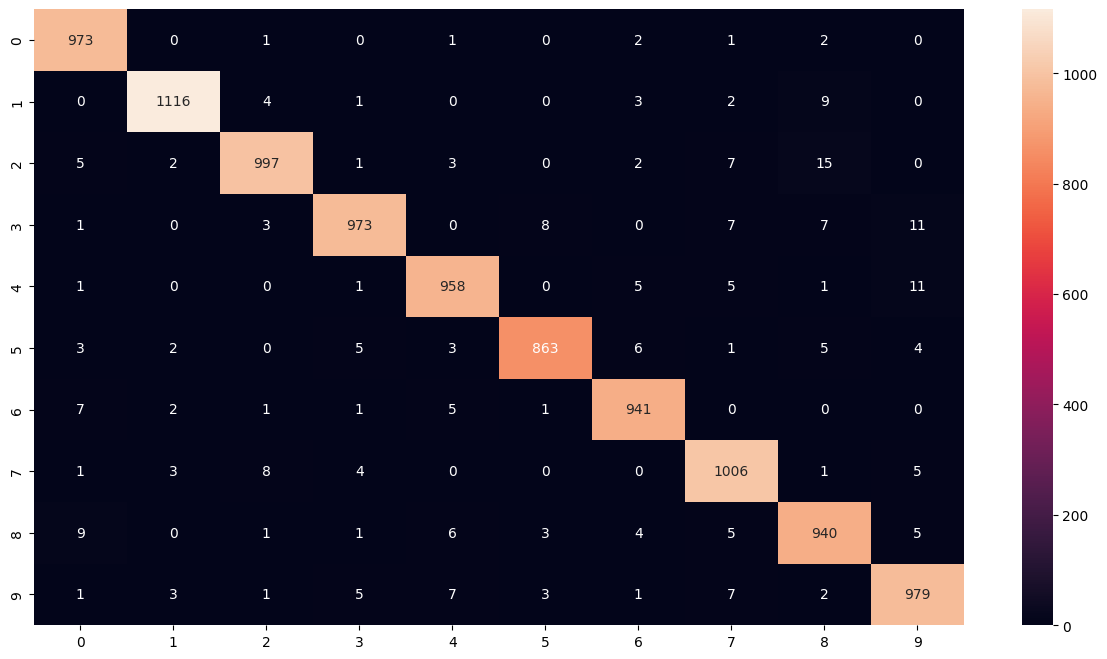

In [ ]:
y_pred= model.predict(x_test_flattened)
y_pred_label= [np.argmax(i) for i in y_pred]

cm= tf.math.confusion_matrix(labels=y_test, predictions=y_pred_label)
plt.figure(figsize=(15,8))
sns. heatmap(data= cm, annot=True, fmt='d')

In [ ]:
model= keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),     # input layer
    keras.layers.Dense(100, activation='relu'),        # hiden layer with 100 neuorns
    keras.layers.Dense(10, activation='sigmoid')])      # outpu layer with 10 output

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 988us/step - loss: 0.2733 - accuracy: 0.9218
Epoch 2/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.1231 - accuracy: 0.9641
Epoch 3/5
1875/1875 [==============================] - 2s 973us/step - loss: 0.0874 - accuracy: 0.9737
Epoch 4/5
1875/1875 [==============================] - 2s 973us/step - loss: 0.0664 - accuracy: 0.9796
Epoch 5/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0529 - accuracy: 0.9836


In [ ]:
model.evaluate(x_train_flattened,y_train)

1875/1875 [==============================] - 2s 847us/step - loss: 0.0356 - accuracy: 0.9899


[0.035631317645311356, 0.989883303642273]

In [ ]:
model.evaluate(x_test,y_test)

313/313 [==============================] - 0s 805us/step - loss: 0.0759 - accuracy: 0.9769


[0.07587157189846039, 0.9768999814987183]